# Screening fixes for model-agreement false alarms (iteration-5 FREEZE, dataset E)

This notebook is a runnable demo of experiment `art_EU1yuNrRl4od` from a study of **gold-free quality metrics for
natural-language → first-order-logic (NL→FOL) translation**.

**The baseline metric (V0 = `c_score_align`).** Several LLM systems formalize the same sentence. Each candidate formula is scored by
how often it *disagrees* with its peers. Disagreement is checked by z3 equivalence after aligning predicate names. Higher score =
more likely an ERROR. No gold formula is used.

**The problem.** Model agreement raises false alarms (**d** = share of CORRECT candidates flagged). It also endorses shared
mistakes (**e** = share of ERROR candidates endorsed).

**What the experiment did.**
* **Part A ($0).** Five label-free rescorings of V0, all computed from the same pairwise-agreement matrix:
  * V1: plurality-normalised
  * V2: reliability-weighted by model family
  * V3: V1 + V2
  * V4: cross-fitted logistic on (c_exact, V0)
  * V5: V3 on a 3-family pool

  Each was screened against V0 by within-stratum AUROC on long, heavily conditioned sentences (LONG = strata L25/L20/EXC).
  The pre-registered rule: a variant wins only if Δ LONG ≥ +0.015, L25 ≥ V0 and CTRL ≥ V0 − 0.01.
  **Result on the full data: `NONE: V0 stands`.**
* **Part B (GG).** A gloss-gated name-free agreement score: exact z3 equivalence, or a symbol map plus an LLM gloss check.
  It halves e but raises d, and fails gate g3 (ALL-strat 0.696 vs V0 0.742).

`method.py` in the original artifact is an **orchestrator** that runs ~25 `src/` scripts in pre-registered order. Those
scripts read multi-GB upstream inputs (pairwise z3 matrices, gold labels), which cannot ship with a demo. This notebook
therefore does two things:
1. It keeps `method.py` itself, split into cells, and runs it as a **dry run** that shows the pipeline plan.
2. It re-runs the **statistical core** of Part A on a 100-row labelled subset (`mini_demo_data.json`). That core is the screen
   (`src/screen.py`), the selection rule with its stability and permutation-null checks (`src/select_rule.py`), and the
   statistics library (`src/stats.py`). The subset holds the frozen per-candidate scores V0–V5, c_exact and gg.

Those files' code is copied with minimal changes. Paths are replaced by the loaded `data`, and loop counts come from the config cell.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (method.py logs with it)
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

In [2]:
from __future__ import annotations

# ---- method.py imports (verbatim)
import argparse
import os
import subprocess
import sys
import time
from pathlib import Path

from loguru import logger

# ---- imports of src/stats.py, src/screen.py, src/select_rule.py, src/labels.py
import json
import math
from collections import Counter, defaultdict
from typing import Sequence

import numpy as np
import pandas as pd
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression

# ---- notebook-only: visualisation
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-5/experiment-14/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
EX = data["datasets"][0]["examples"]
print(data["metadata"]["selection"])
print(len(EX), "rows;", "example row:")
print(json.dumps(json.loads(EX[0]["input"]), indent=1, ensure_ascii=False))
print({k: v for k, v in EX[0].items() if k.startswith("predict_")}, "->", EX[0]["output"])

100 rows: 25 per stratum (L25, L20, EXC, CTRL), 13 ERROR + 12 CORRECT each, seed 20260924, distinct sentences preferred
100 rows; example row:
{
 "text": "When something is depressing, it is sad.",
 "candidate_fol": "∀x (Depressing(x) → Sad(x))",
 "system": "G3:mistralai/mistral-small-3.2-24b-instruct",
 "prompt_variant": "fewshot_v1"
}
{'predict_V0': '0.083333', 'predict_V0_rep': '0.0833333', 'predict_V1': '0', 'predict_V2': '0.0665353', 'predict_V3': '0', 'predict_V4': '0.0574975', 'predict_V5': '0', 'predict_c_exact': '0.0833333', 'predict_gg': '0.0833333', 'predict_gg_allyes': '0.0833333', 'predict_p_peer_text': '0.08786', 'predict_judge_cheap_disg': '0', 'predict_gg_b_allyes': '0.0833333'} -> CORRECT


## Config

Every tunable parameter is set here. Original values from the full run are in the comments.
* `B`: sentence-cluster bootstrap replicates for the AUROC confidence intervals in the screen.
* `B_STAB`: within-stratum resamples for the selection-stability check.
* `B_NULL`: within-stratum label permutations for the permutation null (V4 is re-cross-fitted on each).
* `MAX_ROWS`: how many of the 100 demo rows to use.

In [5]:
MAX_ROWS = 100      # rows of mini_demo_data.json to use (demo subset of population Z; full run: 2,672 Z rows)
B = 2000            # screen bootstrap replicates                     (original: 2000)
B_STAB = 500        # selection-stability resamples                   (original: 500)
B_NULL = 200        # permutation-null replicates                     (original: 200)
SEED = 20260924     # bootstrap seed (original, src/common.py)
DRY_RUN = True      # method.py orchestrator: print the plan only (the src/ scripts and their inputs are not shipped)

## 1. The orchestrator (`method.py`)

`method.py` holds the whole experiment as an ordered table of steps: **stage, script, working dir, marker file**.
* A step is skipped when its marker file already exists. This makes re-runs idempotent: OpenRouter is never re-billed and frozen files are never rewritten.
* The three "immutable writers" (pre-registrations and the Part-A freeze) are never forced.

The stages run in this order:
* **A**: label-free V0–V5 screen, then the freeze.
* **B**: GG, the gloss-gated agreement score.
* **GGB**: secondary bridges.
* **C**: vendored library.
* **OUT**: outputs.
* **TEST**: tests and audits.

The only notebook changes:
* `ROOT` is the notebook's working directory, because `__file__` does not exist in a notebook.
* `main()` takes an `argv` list instead of reading the command line.
* With `DRY_RUN = True`, `main()` logs each step instead of launching the subprocess.

In [6]:
ROOT = Path.cwd()  # original: Path(__file__).resolve().parent
SRC = ROOT / "src"
PY = sys.executable

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")

# (stage, script + args, cwd, output that marks the step done)
STEPS = [
    ("A", ["copy_inputs.py"], SRC, "inputs_manifest.json"),
    ("A", ["step0_gates.py"], SRC, "results/gate_G0.json"),
    ("A", ["prereg_improve.py"], SRC, "prereg_improve.json"),
    ("A", ["make_row_index.py"], SRC, "results/row_index_labelfree.jsonl"),
    ("A", ["score_variants.py"], SRC, "results/scores_E_variants.jsonl"),
    ("A", ["fit_v4.py"], SRC, "results/scores_E_V4.jsonl"),
    ("A", ["screen.py"], SRC, "results/screen_E.json"),
    ("A", ["select_rule.py"], SRC, "results/selection_E.json"),
    ("A", ["freeze_part_a.py"], SRC, "freeze/selection.json"),
    ("B", ["probe.py"], SRC, "results/probe.json"),
    ("B", ["prereg_gg.py"], SRC, "prereg_gg.json"),
    ("B", ["gg_search.py", "all"], SRC, "results/gg_search.jsonl"),
    ("B", ["gg_gates.py", "dev", "v1"], SRC, "results/gg_gates_dev_v1.json"),
    ("B", ["gg_gates.py", "confirm", "v2"], SRC, "results/gg_gates_confirm_v2.json"),
    ("B", ["gg_gloss.py"], SRC, "results/gg_verdicts.json"),
    ("B", ["gg_score.py"], SRC, "results/gg_dev.json"),
    ("B", ["freeze_part_b.py"], SRC, "freeze/gg_gate.json"),
    ("GGB", ["ggb_search.py", "all"], SRC, "results/ggb_search.jsonl"),
    ("GGB", ["ggb_score.py"], SRC, "results/ggb_dev.json"),
    ("C", ["vendor_lib.py"], SRC, "lib/PROVENANCE.json"),
    ("OUT", ["make_outputs.py"], SRC, "method_out.json"),
    ("OUT", ["make_tables.py"], SRC, "tables.md"),
    ("TEST", ["-m", "pytest", "-q", "tests/test_variants.py", "tests/test_gg.py", "tests/test_budget.py"], ROOT, None),
    ("TEST", ["tests/audit_rederive.py"], ROOT, None),
    ("TEST", ["tests/smoke_lib.py"], ROOT, None),
]
NEVER_FORCE = {"prereg_improve.py", "prereg_gg.py", "freeze_part_a.py"}  # immutable writers

In [7]:
@logger.catch(reraise=True)
def main(argv=None):
    ap = argparse.ArgumentParser()
    ap.add_argument("--stage", default="A,B,GGB,C,OUT,TEST")
    ap.add_argument("--force", action="store_true")
    a = ap.parse_args(argv)  # original: ap.parse_args() (command line)
    stages = set(a.stage.split(","))
    env = {**os.environ, "PYTHONHASHSEED": "0"}
    for stage, args, cwd, marker in STEPS:
        if stage not in stages:
            continue
        name = args[0]
        if marker and (ROOT / marker).exists() and (not a.force or name in NEVER_FORCE):
            logger.info(f"[{stage}] skip {' '.join(args)} ({marker} exists)")
            continue
        logger.info(f"[{stage}] run {' '.join(args)}")
        if DRY_RUN:  # notebook-only: src/ and its multi-GB upstream inputs are not part of the demo
            continue
        t0 = time.time()
        try:
            subprocess.run([PY, *args], cwd=cwd, env=env, check=True)
        except subprocess.CalledProcessError as e:
            logger.error(f"[{stage}] {name} failed with exit code {e.returncode}")
            raise
        logger.info(f"[{stage}] {name} done in {time.time() - t0:.0f}s")


main(["--stage", "A,B,GGB,C,OUT,TEST"])

13:30:33|INFO   |[A] run copy_inputs.py


13:30:33|INFO   |[A] run step0_gates.py


13:30:33|INFO   |[A] run prereg_improve.py


13:30:33|INFO   |[A] run make_row_index.py


13:30:33|INFO   |[A] run score_variants.py


...

13:30:33|INFO   |[OUT] run make_outputs.py


13:30:33|INFO   |[OUT] run make_tables.py


13:30:33|INFO   |[TEST] run -m pytest -q tests/test_variants.py tests/test_gg.py tests/test_budget.py


13:30:33|INFO   |[TEST] run tests/audit_rederive.py


13:30:33|INFO   |[TEST] run tests/smoke_lib.py


## 2. Statistics library (`src/stats.py`, verbatim)

**Part 1** (copied unchanged from an earlier experiment) holds:
* Mann-Whitney **AUROC** (ties count ½).
* **Within-stratum AUROC** (`strat_auroc`). Only (ERROR, CORRECT) pairs from the same sentence stratum count, so stratum composition cannot inflate the score.
* A **sentence-cluster bootstrap**. Candidates of the same sentence are resampled together, which keeps CIs honest about non-independence.

**Part 2** is the same bootstrap, written as multiplicity weights for speed (`WAuc`, `WStratAuc`, `SentBoot`).

In [8]:
# ============================================================ Part 1: exp 6 api_bar.py (verbatim)
def auroc(y, s) -> float:
    """Mann-Whitney AUROC, ties counted 1/2 (== sklearn roc_auc_score). nan if one class is empty."""
    y = np.asarray(y)
    s = np.asarray(s, float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auroc(y, s, stratum) -> float:
    """Within-stratum AUROC: sum_h AUC_h * P_h * N_h / sum_h P_h * N_h (only (ERROR, CORRECT) pairs from the same
    source stratum count), identical to exp 5's strat_auc. Removes the stratum-composition part of pooled AUROC."""
    y = np.asarray(y)
    s = np.asarray(s, float)
    stratum = np.asarray(stratum)
    num = den = 0.0
    for h in np.unique(stratum):
        m = stratum == h
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auroc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


class ClusterBoot:
    """Sentence-clustered bootstrap index sets: resample sentence ids with replacement (fixed seed); every metric on a
    row set uses the IDENTICAL resamples, which makes deltas paired."""

    def __init__(self, clusters: Sequence[str], b: int = 2000, seed: int = 0):
        by = defaultdict(list)
        for i, c in enumerate(clusters):
            by[c].append(i)
        keys = sorted(by)
        arr = [np.array(by[k]) for k in keys]
        rng = np.random.default_rng(seed)
        self.idx = []
        for _ in range(b):
            pick = rng.integers(0, len(keys), len(keys))
            self.idx.append(np.concatenate([arr[j] for j in pick]))
        self.n_clusters = len(keys)


def boot_ci(vals, lo: float = 2.5, hi: float = 97.5) -> list:
    v = np.asarray([x for x in vals if x is not None and not (isinstance(x, float) and math.isnan(x))], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


def paired_boot(y, a, c, cb: ClusterBoot, stat: str = "pooled", stratum=None) -> dict:
    """Paired delta stat(a) - stat(c) on identical rows; percentile CI over cluster resamples; one-sided
    p = share of resampled deltas <= 0. stat in {'pooled', 'strat'} (strat needs `stratum`)."""
    y = np.asarray(y)
    a = np.asarray(a, float)
    c = np.asarray(c, float)
    st = None if stratum is None else np.asarray(stratum)
    f = (lambda yy, ss, hh: auroc(yy, ss)) if stat == "pooled" else strat_auroc
    pa, pc = f(y, a, st), f(y, c, st)
    da, dc, dd = [], [], []
    for ix in cb.idx:
        hh = None if st is None else st[ix]
        xa, xc = f(y[ix], a[ix], hh), f(y[ix], c[ix], hh)
        da.append(xa)
        dc.append(xc)
        dd.append(xa - xc)
    dd_ = np.array([d for d in dd if not math.isnan(d)])
    return {"a": pa, "b": pc, "a_ci": boot_ci(da), "b_ci": boot_ci(dc), "delta": pa - pc, "ci": boot_ci(dd),
            "p_one_sided_le0": float(np.mean(dd_ <= 0)) if len(dd_) else None, "se": float(np.std(dd_)) if len(dd_) else None,
            "n": int(len(y)), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()), "stat": stat}


# ============================================================ Part 2: eval-2 stats.py weighted forms (verbatim)
class WAuc:
    """AUROC under row weights (bootstrap multiplicities); ties = 0.5. Precomputes the score ranking once."""

    def __init__(self, y, s):
        self.y = np.asarray(y, float)
        vals, self.inv = np.unique(np.asarray(s, float), return_inverse=True)
        self.nv = len(vals)

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        W1 = np.bincount(self.inv, weights=w * self.y, minlength=self.nv)
        W0 = np.bincount(self.inv, weights=w * (1 - self.y), minlength=self.nv)
        den = W1.sum() * W0.sum()
        if den <= 0:
            return float("nan")
        cum0 = np.cumsum(W0) - W0
        return float((W1 * (cum0 + 0.5 * W0)).sum() / den)


class WStratAuc:
    """Within-stratum pair AUROC under row weights."""

    def __init__(self, y, s, strata):
        self.y = np.asarray(y, float)
        strata = np.asarray(strata)
        self.parts = [(np.where(strata == st)[0], WAuc(self.y[strata == st], np.asarray(s, float)[strata == st]))
                      for st in np.unique(strata)]

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        num = den = 0.0
        for ix, wa in self.parts:
            ww = w[ix]
            n1 = (ww * self.y[ix]).sum()
            n0 = (ww * (1 - self.y[ix])).sum()
            if n1 > 0 and n0 > 0:
                num += wa(ww) * n1 * n0
                den += n1 * n0
        return num / den if den else float("nan")


class SentBoot:
    """Sentence-cluster bootstrap as multiplicity weights: W[b, i] = #times row i's sentence was drawn in replicate b."""

    def __init__(self, sids, b: int = 2000, seed: int = 0):
        sids = np.asarray(sids)
        self.keys, self.sent_ix = np.unique(sids, return_inverse=True)
        S = len(self.keys)
        rng = np.random.default_rng(seed)
        self.C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        self.B = b

    def W(self, mask=None):
        W = self.C[:, self.sent_ix]
        return W if mask is None else W[:, mask]


# ============================================================ vectorised helpers (this artifact)
def boot_series(y, s, strata, W, stat: str = "strat") -> np.ndarray:
    """Replicate values of (strat|pooled) AUROC under a (B, n) weight matrix."""
    f = WStratAuc(y, s, strata) if stat == "strat" else WAuc(y, s)
    return np.array([f(w) for w in W])


def point(y, s, strata, stat: str = "strat") -> float:
    return strat_auroc(y, s, strata) if stat == "strat" else auroc(y, s)


def rate_ci(num_mask, den_mask, W) -> list:
    """CI of a ratio sum(w*num)/sum(w*den) over replicates."""
    with np.errstate(invalid="ignore", divide="ignore"):
        v = (W @ num_mask.astype(float)) / (W @ den_mask.astype(float))
    return boot_ci(v)

## 3. The labelled frame (`src/labels.py` + `src/common.py`)

The original `frame()` joins the sealed label-free variant scores (`results/scores_E_variants.jsonl`) with the gold labels
(`per_item_T1.jsonl`) after checking the seal hash. Here the same columns come from the demo rows:
* `y`: 1 = ERROR.
* `V0_frozen`, `V0_rep`, `c_exact`, `V1`–`V5`, `gg`, `judge_cheap_disg` (a cheap LLM-judge baseline).
* Sentence id, stratum, fold, word count and the error operations.

The derived columns (`long`, `words_t` terciles, `t9` error classes, `opc`) use the original code verbatim.
Strata:
* L25: ≥ 25 words.
* L20: 20–24 words.
* EXC: sentences with exceptions.
* CTRL: short control sentences.

In [9]:
# ---- src/common.py constants
STRATA = ("L25", "L20", "EXC", "CTRL")
LONG = ("L25", "L20", "EXC")

# ---- src/labels.py (verbatim)
COARSE = {"ADD": "COVERAGE", "DROP": "COVERAGE", "NEG": "POLARITY", "REV": "POLARITY", "QUANT": "POLARITY"}
T9 = ["ADD", "DROP", "COMPOUND", "polarity(NEG/REV/QUANT)", "structural(CONN/RESTR/BIND/MOVE/SWAP/SCOPE/UNGLUE)",
      "MEANING_RENAME-type (MEANING_RENAME op or tier-B VOCAB_GRAN)"]


def op_class(ops) -> str:
    """eval-2 vendor_exp5/vendor_c/common.py op_class (verbatim)."""
    ops = list(ops) if ops is not None and not isinstance(ops, float) else []
    if not ops:
        return "NONE"
    cs = {COARSE.get(o, "STRUCT") for o in ops}
    return cs.pop() if len(cs) == 1 else "MIXED"


def t9_classes(error_ops, auto_label) -> list[str]:
    """exp 9 src/analyse.py (e) classes(r), verbatim logic."""
    ops = set(error_ops or [])
    out = []
    if "ADD" in ops: out.append("ADD")
    if "DROP" in ops: out.append("DROP")
    if "COMPOUND" in ops: out.append("COMPOUND")
    if ops & {"NEG", "REV", "QUANT"}: out.append("polarity(NEG/REV/QUANT)")
    if ops & {"CONN", "RESTR", "BIND", "MOVE", "SWAP", "SCOPE", "UNGLUE"}: out.append("structural(CONN/RESTR/BIND/MOVE/SWAP/SCOPE/UNGLUE)")
    if "MEANING_RENAME" in ops or auto_label == "VOCAB_GRAN": out.append("MEANING_RENAME-type (MEANING_RENAME op or tier-B VOCAB_GRAN)")
    return out


def frame() -> pd.DataFrame:
    """Demo version: the rows of mini_demo_data.json (already restricted to population Z) as the frame the post-seal
    scripts use. Original: sealed scores_E_variants.jsonl joined with per_item_T1.jsonl labels (check_seal first)."""
    rows = []
    for r in EX[:MAX_ROWS]:
        inp = json.loads(r["input"])
        rows.append({"row_key": r["metadata_row_key"], "sentence_id": r["metadata_sentence_id"], "stratum": r["metadata_stratum"],
                     "fold": r["metadata_fold"], "y_R_AB": r["metadata_y_R_AB"], "R_AB": r["metadata_in_R_AB"], "Z": r["metadata_in_Z"],
                     "V0_frozen": r["predict_V0"], "V0_rep": float(r["predict_V0_rep"]), "c_exact": float(r["predict_c_exact"]),
                     **{v: float(r[f"predict_{v}"]) for v in ["V1", "V2", "V3", "V4", "V5"]},
                     "gg": float(r["predict_gg"]), "judge_cheap_disg": float(r["predict_judge_cheap_disg"]),
                     "p_peer_text": float(r["predict_p_peer_text"]),
                     "words": r["metadata_words"], "n_conditions": r["metadata_n_conditions"], "n_peers": r["metadata_n_peers"],
                     "error_ops": r["metadata_error_ops"], "auto_label": None, "family": r["metadata_family"],
                     "system": inp["system"], "text": inp["text"], "candidate_fol": inp["candidate_fol"]})
    df = pd.DataFrame(rows)
    df["y"] = df.y_R_AB
    df["long"] = df.stratum.isin(["L25", "L20", "EXC"])
    df["words_t"] = np.where(df.words <= 20, "T1", np.where(df.words <= 26, "T2", "T3"))
    df["t9"] = [t9_classes(o, a) if y == 1 else [] for o, a, y in zip(df.error_ops, df.auto_label, df.y)]
    df["opc"] = [op_class(o) for o in df.error_ops]
    return df


df = frame()
print(df.groupby(["stratum", "y"]).size().unstack(), "\n")
print(df[["system", "stratum", "y", "V0_frozen", "V1", "V2", "V4", "gg"]].head(8).to_string())

y         0   1
stratum        
CTRL     12  13
EXC      12  13
L20      12  13
L25      12  13 

                                        system stratum  y V0_frozen        V1        V2        V4        gg
0  G3:mistralai/mistral-small-3.2-24b-instruct    CTRL  0  0.083333  0.000000  0.066535  0.057497  0.083333
1                 G2:qwen/qwen3-235b-a22b-2507     L20  0  0.454545  0.000000  0.436267  0.686328  1.000000
2                             F:openai/gpt-5.1     L20  1  0.454545  0.000000  0.449519  0.395879  0.545455
3        G1b:meta-llama/llama-3.3-70b-instruct     L20  1         1  1.000000  1.000000  0.843593  1.000000
4                           G6:microsoft/phi-4     L20  0      0.75  0.250000  0.686681  0.711444  0.750000
5                 G2:qwen/qwen3-235b-a22b-2507     L25  0  0.909091  0.666667  0.898233  0.761313  0.909091
6                    G4:deepseek/deepseek-v3.2     L25  0  0.333333  0.000000  0.321007  0.315746  0.583333
7                             F:openai

## 4. The screen (`src/screen.py`)

For every score and every cell, this computes the AUROC with sentence-cluster bootstrap CIs.
* The cells are ALL-strat, pooled, LONG-strat, L25, L20, EXC and CTRL.
* It also computes the **paired Δ vs V0** on identical resamples.

It then binarises each score at c > 0.5. V4 is instead thresholded to match V0's flag rate. From the binary flags it reports:
* **e** (errors endorsed) and **d** (correct candidates flagged).
* The key diagnostic: *does any variant lower d without raising e?*

Omitted here because they need upstream files that are not shipped:
* The post-seal reproduction checks (they need `c3_plain` and the full 2,672-row Z).
* The eval-3 oracle bound (it needs the pairwise z3 matrix).
* The extra judge columns.

In [10]:
VARIANTS = ["V1", "V2", "V3", "V4", "V5"]
SCORES = ["V0_frozen", "V0_rep", "c_exact"] + VARIANTS
JUDGES = ["judge_cheap_disg"]  # original also had judge_cheap_orig, judge_cheap2_orig (not in the released outputs)
CELLS = {"ALL-strat": (None, "strat"), "pooled": (None, "pooled"), "LONG-strat": (LONG, "strat"),
         "L25": (("L25",), "pooled"), "L20": (("L20",), "pooled"), "EXC": (("EXC",), "pooled"), "CTRL": (("CTRL",), "pooled")}


def flags(df: pd.DataFrame, P: pd.DataFrame) -> dict:
    """Binary flag per score: c > 0.5; V4 at the threshold matching V0's flag rate on Z (ties broken by row order)."""
    out = {s: (P[s].astype(float).values > 0.5) for s in SCORES if s != "V4"}
    rate = out["V0_frozen"].mean()
    v = P["V4"].astype(float).values
    thr = float(np.quantile(v, 1 - rate, method="higher"))
    f4 = v > thr
    if abs(f4.mean() - rate) > 0.01:  # step ties: take the top-k by score (stable by row order)
        k = int(round(rate * len(v)))
        o = np.argsort(-v, kind="stable")
        f4 = np.zeros(len(v), bool)
        f4[o[:k]] = True
    out["V4"] = f4
    out["_V4_threshold"] = thr
    out["_V0_flag_rate"] = float(rate)
    return out


def auc_block(y, s, st, W, stat):
    pt = strat_auroc(y, s, st) if stat == "strat" else auroc(y, s)
    f = WStratAuc(y, s, st) if stat == "strat" else WAuc(y, s)
    bs = np.array([f(w) for w in W])
    return pt, bs


def ed_block(y, fl, W) -> dict:
    y = np.asarray(y, int)
    endorsed = ~fl
    e = float(endorsed[y == 1].mean()) if (y == 1).any() else None
    d = float(fl[y == 0].mean()) if (y == 0).any() else None
    with np.errstate(invalid="ignore", divide="ignore"):
        eb = (W @ (endorsed & (y == 1)).astype(float)) / (W @ (y == 1).astype(float))
        db = (W @ (fl & (y == 0)).astype(float)) / (W @ (y == 0).astype(float))
    return {"e": e, "d": d, "e_ci": boot_ci(eb), "d_ci": boot_ci(db), "n_err": int((y == 1).sum()), "n_cor": int((y == 0).sum()),
            "auroc_b": (1 - (e + d) / 2) if e is not None and d is not None else None, "_eb": eb, "_db": db}

### 4a. AUROC per cell and paired Δ vs V0

This is the body of `screen.main()`. It is unchanged apart from dropping the reproduction asserts and the file writes.

In [11]:
t0 = time.time()
P = df[df.Z].reset_index(drop=True)
P["V0_frozen"] = P.V0_frozen.astype(float)
y = P.y.values.astype(int)
st = P.stratum.values
boot = SentBoot(P.sentence_id.values, b=B, seed=SEED)
Wf = boot.W()
A = {"population": {"Z_demo": {"n": len(P), "n_error": int(y.sum()), "n_correct": int((1 - y).sum()), "n_sentences": int(P.sentence_id.nunique())}},
     "B": B, "seed": SEED}
# ---------------- AUROC per cell
A["auroc"], A["delta_vs_V0"], A["delta_vs_judges"] = {}, {}, {}
rows_auc, rows_d = [], []
for cname, (strata, stat) in CELLS.items():
    m = np.ones(len(P), bool) if strata is None else np.isin(st, strata)
    W = Wf[:, m]
    ser = {}
    for s in SCORES + JUDGES:
        v = P[s].astype(float).values[m]
        if np.isnan(v).any():
            logger.warning(f"{s} has {np.isnan(v).sum()} NaN in {cname}")
            continue
        ser[s] = auc_block(y[m], v, st[m], W, stat)
    A["auroc"][cname] = {s: {"auroc": pt, "ci": boot_ci(bs), "n": int(m.sum()), "n_err": int(y[m].sum()), "n_cor": int((1 - y[m]).sum()),
                             "n_sent": int(P.sentence_id[m].nunique())} for s, (pt, bs) in ser.items()}
    A["delta_vs_V0"][cname] = {}
    for s in ["V0_rep", "c_exact"] + VARIANTS:
        d = ser[s][1] - ser["V0_frozen"][1]
        A["delta_vs_V0"][cname][s] = {"delta": ser[s][0] - ser["V0_frozen"][0], "ci": boot_ci(d), "se": float(np.nanstd(d)),
                                      "p_one_sided_le0": float(np.nanmean(d <= 0))}
        rows_d.append({"cell": cname, "variant": s, **A["delta_vs_V0"][cname][s]})
    A["delta_vs_judges"][cname] = {}
    for s in ["V0_frozen"] + VARIANTS:
        for j in JUDGES:
            d = ser[s][1] - ser[j][1]
            A["delta_vs_judges"][cname][f"{s} - {j}"] = {"delta": ser[s][0] - ser[j][0], "ci": boot_ci(d)}
    for s, (pt, bs) in ser.items():
        rows_auc.append({"cell": cname, "stat": stat, "score": s, "auroc": pt, "ci_lo": boot_ci(bs)[0], "ci_hi": boot_ci(bs)[1], "n": int(m.sum())})
    logger.info(f"{cname}: " + " ".join(f"{s}={ser[s][0]:.4f}" for s in SCORES))
print(f"AUROC block done in {time.time() - t0:.1f}s")

13:30:34|INFO   |ALL-strat: V0_frozen=0.7812 V0_rep=0.7812 c_exact=0.7700 V1=0.7364 V2=0.7917 V3=0.7372 V4=0.8381 V5=0.7540


13:30:35|INFO   |pooled: V0_frozen=0.7528 V0_rep=0.7528 c_exact=0.7288 V1=0.7368 V2=0.7640 V3=0.7310 V4=0.7839 V5=0.7464


13:30:36|INFO   |LONG-strat: V0_frozen=0.7767 V0_rep=0.7767 c_exact=0.7179 V1=0.7639 V2=0.7959 V3=0.7714 V4=0.8205 V5=0.7703


13:30:36|INFO   |L25: V0_frozen=0.6603 V0_rep=0.6603 c_exact=0.6314 V1=0.6314 V2=0.6667 V3=0.6442 V4=0.7500 V5=0.7051


13:30:36|INFO   |L20: V0_frozen=0.8333 V0_rep=0.8333 c_exact=0.7147 V1=0.8397 V2=0.8622 V3=0.8301 V4=0.8269 V5=0.8333


13:30:36|INFO   |EXC: V0_frozen=0.8365 V0_rep=0.8365 c_exact=0.8077 V1=0.8205 V2=0.8590 V3=0.8397 V4=0.8846 V5=0.7724


13:30:37|INFO   |CTRL: V0_frozen=0.7949 V0_rep=0.7949 c_exact=0.9263 V1=0.6538 V2=0.7788 V3=0.6346 V4=0.8910 V5=0.7051


AUROC block done in 3.5s


### 4b. Error endorsement e and false alarms d

These are the binary flags, the per-cut e/d with bootstrap CIs, and the **key diagnostic**: Δd and Δe vs V0, with a flag for
"d falls without e rising".
* **NET Δ(e+d)**, T3 − T1, asks how much worse the metric gets on long sentences.
* The per-error-class endorsement uses the T9 classes.

In [12]:
FL = flags(df, P)
A["binary"] = {"V4_threshold_flag_rate_matched": FL["_V4_threshold"], "V0_flag_rate": FL["_V0_flag_rate"],
               "flag_rates": {s: float(FL[s].mean()) for s in SCORES}}
cuts = {"ALL": np.ones(len(P), bool), "LONG": P.long.values, "L25": st == "L25", "L20": st == "L20", "EXC": st == "EXC", "CTRL": st == "CTRL",
        "words_T1": P.words_t.values == "T1", "words_T2": P.words_t.values == "T2", "words_T3": P.words_t.values == "T3"}
ED, rows_ed = {}, []
for c, m in cuts.items():
    ED[c] = {}
    for s in SCORES:
        r = ed_block(y[m], FL[s][m], Wf[:, m])
        ED[c][s] = r
        rows_ed.append({"cut": c, "score": s, **{k: v for k, v in r.items() if not k.startswith("_")}})
# key diagnostic: Δd, Δe vs V0 on T3 and L25 (+ LONG, ALL)
A["key_diagnostic"] = {}
for c in ("words_T3", "L25", "LONG", "ALL", "CTRL"):
    A["key_diagnostic"][c] = {}
    for s in ["c_exact"] + VARIANTS:
        a, b = ED[c][s], ED[c]["V0_frozen"]
        A["key_diagnostic"][c][s] = {"d": a["d"], "e": a["e"], "d_V0": b["d"], "e_V0": b["e"],
                                     "delta_d": a["d"] - b["d"], "delta_d_ci": boot_ci(a["_db"] - b["_db"]),
                                     "delta_e": a["e"] - b["e"], "delta_e_ci": boot_ci(a["_eb"] - b["_eb"]),
                                     "d_falls_without_e_rising": bool(boot_ci(a["_db"] - b["_db"])[1] < 0 and boot_ci(a["_eb"] - b["_eb"])[0] <= 0)}
# NET Δ(e+d) T3 - T1 (eval-2 definition)
A["NET_T3_minus_T1"] = {}
for s in SCORES:
    t3, t1 = ED["words_T3"][s], ED["words_T1"][s]
    net = (t3["e"] + t3["d"]) - (t1["e"] + t1["d"])
    nb = (t3["_eb"] + t3["_db"]) - (t1["_eb"] + t1["_db"])
    A["NET_T3_minus_T1"][s] = {"net": net, "ci": boot_ci(nb), "delta_e": t3["e"] - t1["e"], "delta_d": t3["d"] - t1["d"]}
# per T9 class e (ERROR rows of the class) and d reference
A["t9_e"] = {}
rows_t9 = []
for cl in T9:
    m = np.array([cl in x for x in P.t9])
    A["t9_e"][cl] = {"n": int(m.sum())}
    for s in SCORES:
        if m.sum() == 0:
            continue
        en = ~FL[s][m]
        eb = (Wf[:, m] @ en.astype(float)) / Wf[:, m].sum(1)
        A["t9_e"][cl][s] = {"e": float(en.mean()), "e_ci": boot_ci(eb)}
        rows_t9.append({"class": cl, "score": s, "n": int(m.sum()), "e": float(en.mean()), "e_ci_lo": boot_ci(eb)[0], "e_ci_hi": boot_ci(eb)[1]})
A["ed"] = {c: {s: {k: v for k, v in r.items() if not k.startswith("_")} for s, r in d.items()} for c, d in ED.items()}
A["runtime_s"] = time.time() - t0

kd = pd.DataFrame({s: {k: A["key_diagnostic"]["ALL"][s][k] for k in ("d_V0", "d", "e_V0", "e", "d_falls_without_e_rising")}
                   for s in ["c_exact"] + VARIANTS}).T
print("Key diagnostic (ALL demo rows):\n", kd.to_string())

Key diagnostic (ALL demo rows):
              d_V0         d      e_V0         e d_falls_without_e_rising
c_exact  0.479167      0.75  0.230769  0.038462                    False
V1       0.479167  0.166667  0.230769  0.423077                    False
V2       0.479167  0.479167  0.230769  0.211538                    False
V3       0.479167  0.166667  0.230769  0.384615                    False
V4       0.479167  0.458333  0.230769  0.211538                    False
V5       0.479167  0.208333  0.230769  0.326923                     True


/tmp/ipykernel_488/3611417015.py:40: RuntimeWarning: invalid value encountered in divide
  eb = (Wf[:, m] @ en.astype(float)) / Wf[:, m].sum(1)


## 5. The pre-registered selection rule (`src/select_rule.py`)

The rule is applied mechanically:
* The winner is the variant with the highest LONG-strat AUROC that meets all three conditions:
  * (i) it beats V0 by ≥ +0.015 there;
  * (ii) it is ≥ V0 on L25;
  * (iii) it is ≥ V0 − 0.01 on CTRL.
* If no variant qualifies, the answer is `NONE: V0 stands`.

Two checks are reported but do not gate the decision:
* **(a) Stability.** How often each decision is picked under within-stratum sentence resamples (`B_STAB`).
* **(b) Permutation null.** How often *some* variant "qualifies" when labels are permuted within strata. V4 is re-cross-fitted on each permuted label vector (`B_NULL`).

In [13]:
COST_RANK = {"V5": 0, "V1": 1, "V2": 1, "V3": 1, "V4": 1}
MARGIN, L25_TOL, CTRL_TOL, TIE = 0.015, 0.0, 0.01, 1e-4
RULE_TEXT = ("winner = variant with highest E LONG-strat AUROC (Z) that (i) beats V0 by >= +0.015 there AND (ii) >= V0 on L25 "
             "(point) AND (iii) >= V0 - 0.01 on CTRL; none -> 'NONE: V0 stands'; tie (|Δ| < 1e-4) -> cheaper (V5 < others)")


def rule(stats: dict) -> tuple[str, dict]:
    """stats[v] = {'LONG', 'L25', 'CTRL'} for v in V0 + VARIANTS -> (winner, per-variant qualification)."""
    q = {}
    for v in VARIANTS:
        c1 = stats[v]["LONG"] - stats["V0"]["LONG"] >= MARGIN
        c2 = stats[v]["L25"] >= stats["V0"]["L25"] - L25_TOL
        c3 = stats[v]["CTRL"] >= stats["V0"]["CTRL"] - CTRL_TOL
        q[v] = {"i_long_margin": bool(c1), "ii_L25": bool(c2), "iii_CTRL": bool(c3), "qualifies": bool(c1 and c2 and c3),
                "delta_long": stats[v]["LONG"] - stats["V0"]["LONG"]}
    ok = [v for v in VARIANTS if q[v]["qualifies"]]
    if not ok:
        return "NONE: V0 stands", q
    best = max(stats[v]["LONG"] for v in ok)
    tied = [v for v in ok if best - stats[v]["LONG"] < TIE]
    return sorted(tied, key=lambda v: (COST_RANK[v], v))[0], q


def cell_stats(y, S, st, w=None) -> dict:
    """LONG-strat, L25 pooled, CTRL pooled AUROC for each score column in S (dict name -> array); w = row weights."""
    out = {}
    L = np.isin(st, ["L25", "L20", "EXC"])
    for name, s in S.items():
        if w is None:
            out[name] = {"LONG": strat_auroc(y[L], s[L], st[L]), "L25": auroc(y[st == "L25"], s[st == "L25"]),
                         "CTRL": auroc(y[st == "CTRL"], s[st == "CTRL"])}
        else:
            out[name] = {"LONG": WStratAuc(y[L], s[L], st[L])(w[L]), "L25": WAuc(y[st == "L25"], s[st == "L25"])(w[st == "L25"]),
                         "CTRL": WAuc(y[st == "CTRL"], s[st == "CTRL"])(w[st == "CTRL"])}
    return out


def v4_oof(X, y, fold):
    p = np.zeros(len(y))
    for k in range(5):
        tr, te = fold != k, fold == k
        m = LogisticRegression(C=1e6, max_iter=2000).fit(X[tr], y[tr])
        p[te] = m.predict_proba(X[te])[:, 1]
    return p

### 5a. Decision on the demo rows

In [14]:
obs = {v: {"LONG": A["auroc"]["LONG-strat"][v]["auroc"], "L25": A["auroc"]["L25"][v]["auroc"], "CTRL": A["auroc"]["CTRL"][v]["auroc"]}
       for v in VARIANTS}
obs["V0"] = {"LONG": A["auroc"]["LONG-strat"]["V0_frozen"]["auroc"], "L25": A["auroc"]["L25"]["V0_frozen"]["auroc"],
             "CTRL": A["auroc"]["CTRL"]["V0_frozen"]["auroc"]}
winner, q = rule(obs)
logger.info(f"DECISION: {winner}; " + json.dumps({v: round(q[v]['delta_long'], 4) for v in VARIANTS}))
print(pd.DataFrame(q).T.to_string())

13:30:37|INFO   |DECISION: V4; {"V1": -0.0128, "V2": 0.0192, "V3": -0.0053, "V4": 0.0438, "V5": -0.0064}


   i_long_margin ii_L25 iii_CTRL qualifies delta_long
V1         False  False    False     False  -0.012821
V2          True   True    False     False   0.019231
V3         False  False    False     False  -0.005342
V4          True   True     True      True   0.043803
V5         False   True    False     False   -0.00641


### 5b. Stability (within-stratum sentence resamples) and permutation null

In [15]:
t1 = time.time()
# ---------------- (a) stability: within-stratum sentence resamples
S = {v: P[v].astype(float).values for v in VARIANTS}
S["V0"] = P.V0_frozen.astype(float).values
rng = np.random.default_rng(SEED + 1)
sids = P.sentence_id.values
by_stratum = {h: np.unique(sids[st == h]) for h in np.unique(st)}
sent_ix = {s: i for i, s in enumerate(np.unique(sids))}
row_sent = np.array([sent_ix[s] for s in sids])
picks = []
for b in range(B_STAB):  # original: range(500)
    cnt = np.zeros(len(sent_ix))
    for h, ss in by_stratum.items():
        draw = rng.integers(0, len(ss), len(ss))
        np.add.at(cnt, [sent_ix[x] for x in ss[draw]], 1)
    w = cnt[row_sent]
    wb, _ = rule(cell_stats(y, S, st, w))
    picks.append(wb)
stab = {k: v / B_STAB for k, v in Counter(picks).items()}
logger.info(f"stability {stab}")
# ---------------- (b) permutation null
rng2 = np.random.default_rng(SEED + 2)
X4 = np.column_stack([P.c_exact.astype(float).values, P.V0_frozen.astype(float).values])
fold = P.fold.values
any_q = 0
per_v = Counter()
for b in range(B_NULL):  # original: range(200)
    yp = y.copy()
    for h in np.unique(st):
        m = np.where(st == h)[0]
        yp[m] = rng2.permutation(y[m])
    Sb = dict(S)
    Sb["V4"] = v4_oof(X4, yp, fold)
    wb, qb = rule(cell_stats(yp, Sb, st))
    if wb != "NONE: V0 stands":
        any_q += 1
    for v in VARIANTS:
        per_v[v] += qb[v]["qualifies"]
null = {"B": B_NULL, "share_any_variant_qualifies": any_q / B_NULL, "share_per_variant": {v: per_v[v] / B_NULL for v in VARIANTS},
        "note": "within-stratum label permutation of Z; V4 re-cross-fitted on each permuted label vector"}
logger.info(f"null {null}")
selection = {"winner": winner, "rule_text": RULE_TEXT, "observed": obs, "qualification": q, "n_screened": 5,
             "margin": MARGIN, "stability": {"B": B_STAB, "scheme": "sentence-cluster resample within strata", "share_selected": stab},
             "permutation_null": null}
print(f"stability + null done in {time.time() - t1:.1f}s")

13:30:38|INFO   |stability {'NONE: V0 stands': 0.184, 'V2': 0.078, 'V4': 0.708, 'V5': 0.028, 'V3': 0.002}


13:30:40|INFO   |null {'B': 200, 'share_any_variant_qualifies': 0.27, 'share_per_variant': {'V1': 0.115, 'V2': 0.055, 'V3': 0.1, 'V4': 0.04, 'V5': 0.11}, 'note': 'within-stratum label permutation of Z; V4 re-cross-fitted on each permuted label vector'}


stability + null done in 2.8s


## 6. Part B headline: the GG gate g3 on the demo rows

GG (gloss-gated name-free agreement) was computed upstream. That run needed z3 symbol-map search plus gemini-2.5-flash gloss
checks, and its per-row scores are stored in the data. Gate **g3** requires GG's ALL-strat AUROC to be at least V0's.
On the full data it fails: 0.696 vs 0.742, Δ −0.046 [−0.071, −0.021]. This cell is a notebook addition. It re-checks g3 on the
demo rows with the same `paired_boot` helper from `stats.py`.

In [16]:
cb = ClusterBoot(P.sentence_id.values, b=B, seed=SEED)
g3 = paired_boot(y, P.gg.values, P.V0_frozen.values, cb, stat="strat", stratum=st)
fl_gg = P.gg.values > 0.5
print(f"g3 (ALL-strat): GG {g3['a']:.3f} vs V0 {g3['b']:.3f}; Δ {g3['delta']:+.3f} CI [{g3['ci'][0]:+.3f}, {g3['ci'][1]:+.3f}]"
      f" -> {'PASS' if g3['delta'] >= 0 else 'FAIL'}(g3)")
print(f"GG  e = {(~fl_gg[y == 1]).mean():.3f}   d = {fl_gg[y == 0].mean():.3f}")
print(f"V0  e = {(~FL['V0_frozen'][y == 1]).mean():.3f}   d = {FL['V0_frozen'][y == 0].mean():.3f}")

g3 (ALL-strat): GG 0.776 vs V0 0.781; Δ -0.006 CI [-0.088, +0.077] -> FAIL(g3)
GG  e = 0.173   d = 0.667
V0  e = 0.231   d = 0.479


## 7. Results

The demo numbers (100 rows) are shown next to the full-run numbers on all 2,672 Z rows, which are stored in the data file's metadata.
With 100 rows the CIs are wide, so read the demo as a check that the mechanics work, not a replication. The mechanical
decision on so few rows can differ from the full run. On this subset V4 clears the +0.015 margin, but the stability check
shows how fragile that is. The permutation null shows the same: on 100 rows, some variant "qualifies" in a large share of
label-permuted replicates, against 3.5% on the full data. In the full run V4 was the most frequent runner-up, picked in 11.8%
of resamples. The pattern to look for is the full-run finding:
* **No variant beats V0 by the required margin on LONG sentences.**
* **Plurality normalisation (V1/V3/V5) trades d for e.** It lowers false alarms and raises error endorsement.

           score  demo LONG-strat    demo 95% CI  full LONG-strat  demo ALL-strat  full ALL-strat  demo Δ LONG vs V0  demo d  demo e
       V0_frozen           0.7767 [0.653, 0.885]           0.7426          0.7812          0.7422                NaN  0.4792  0.2308
              V1           0.7639 [0.640, 0.875]           0.7392          0.7364          0.7290            -0.0128  0.1667  0.4231
              V2           0.7959 [0.673, 0.898]           0.7501          0.7917          0.7523             0.0192  0.4792  0.2115
              V3           0.7714 [0.643, 0.885]           0.7500          0.7372          0.7374            -0.0053  0.1667  0.3846
              V4           0.8205 [0.711, 0.912]           0.7514          0.8381          0.7583             0.0438  0.4583  0.2115
              V5           0.7703 [0.656, 0.873]           0.7456          0.7540          0.7349            -0.0064  0.2083  0.3269
         c_exact           0.7179 [0.611, 0.815]           0.6724    

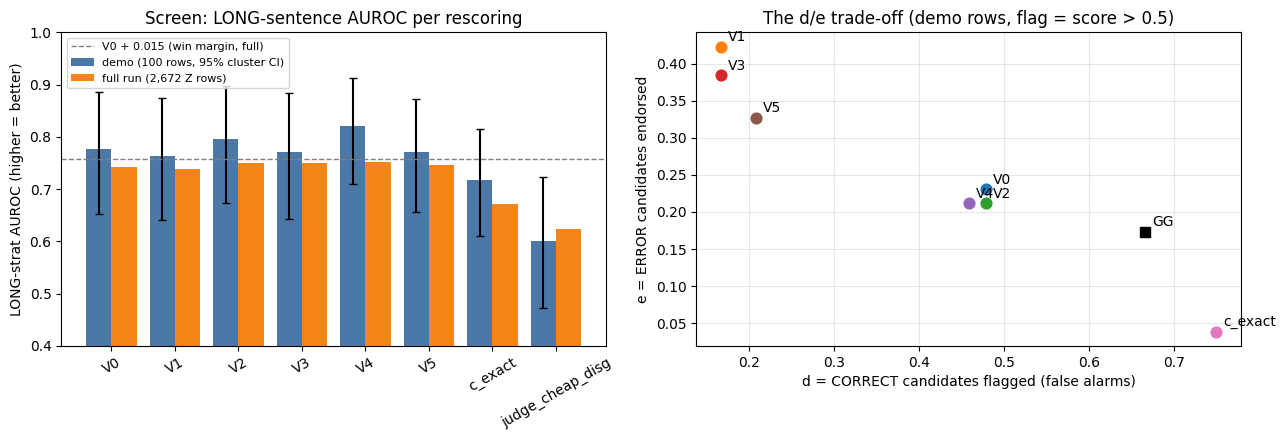

In [17]:
REF = data["metadata"]["reference_full_Z_auroc"]
names = ["V0_frozen", "V1", "V2", "V3", "V4", "V5", "c_exact", "judge_cheap_disg"]
ref_key = lambda s: "V0" if s == "V0_frozen" else s
tab = pd.DataFrame([{
    "score": s,
    "demo LONG-strat": A["auroc"]["LONG-strat"][s]["auroc"],
    "demo 95% CI": "[{:.3f}, {:.3f}]".format(*A["auroc"]["LONG-strat"][s]["ci"]),
    "full LONG-strat": REF[ref_key(s)]["LONG-strat"],
    "demo ALL-strat": A["auroc"]["ALL-strat"][s]["auroc"],
    "full ALL-strat": REF[ref_key(s)]["ALL-strat"],
    "demo Δ LONG vs V0": (A["delta_vs_V0"]["LONG-strat"][s]["delta"] if s in A["delta_vs_V0"]["LONG-strat"] else np.nan),
    "demo d": A["ed"]["ALL"][s]["d"] if s in A["ed"]["ALL"] else np.nan,
    "demo e": A["ed"]["ALL"][s]["e"] if s in A["ed"]["ALL"] else np.nan,
} for s in names])
pd.set_option("display.width", 200)
print(tab.round(4).to_string(index=False))
print(f"\nDemo decision : {selection['winner']}   | full-run decision: {data['metadata']['reference_part_A_winner']}")
print(f"Demo stability: {selection['stability']['share_selected']}")
print(f"Full stability: {data['metadata']['reference_part_A_stability']['share_selected']}")
print(f"Demo null (any variant qualifies): {null['share_any_variant_qualifies']:.3f}   | full: {data['metadata']['reference_part_A_null']['share_any_variant_qualifies']}")
print(f"GG status (full run): {data['metadata']['reference_GG_status']}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(names))
demo = [A["auroc"]["LONG-strat"][s]["auroc"] for s in names]
lo = [demo[i] - A["auroc"]["LONG-strat"][s]["ci"][0] for i, s in enumerate(names)]
hi = [A["auroc"]["LONG-strat"][s]["ci"][1] - demo[i] for i, s in enumerate(names)]
ax[0].bar(x - 0.2, demo, 0.4, yerr=[lo, hi], capsize=3, label=f"demo ({len(P)} rows, 95% cluster CI)", color="#4C78A8")
ax[0].bar(x + 0.2, [REF[ref_key(s)]["LONG-strat"] for s in names], 0.4, label="full run (2,672 Z rows)", color="#F58518")
ax[0].axhline(REF["V0"]["LONG-strat"] + MARGIN, ls="--", c="gray", lw=1, label="V0 + 0.015 (win margin, full)")
ax[0].set_xticks(x, [ref_key(s) for s in names], rotation=30)
ax[0].set_ylim(0.4, 1.0)
ax[0].set_ylabel("LONG-strat AUROC (higher = better)")
ax[0].set_title("Screen: LONG-sentence AUROC per rescoring")
ax[0].legend(fontsize=8, loc="upper left")

for s in ["V0_frozen", "V1", "V2", "V3", "V4", "V5", "c_exact"]:
    ax[1].scatter(A["ed"]["ALL"][s]["d"], A["ed"]["ALL"][s]["e"], s=60)
    ax[1].annotate(ref_key(s), (A["ed"]["ALL"][s]["d"], A["ed"]["ALL"][s]["e"]), textcoords="offset points", xytext=(5, 4))
ax[1].scatter((fl_gg[y == 0]).mean(), (~fl_gg[y == 1]).mean(), s=60, marker="s", c="k")
ax[1].annotate("GG", ((fl_gg[y == 0]).mean(), (~fl_gg[y == 1]).mean()), textcoords="offset points", xytext=(5, 4))
ax[1].set_xlabel("d = CORRECT candidates flagged (false alarms)")
ax[1].set_ylabel("e = ERROR candidates endorsed")
ax[1].set_title("The d/e trade-off (demo rows, flag = score > 0.5)")
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()